In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, util, morphology, measure, filters
from skimage.color import rgb2gray
from scipy import ndimage

from PIL import Image, ImageDraw

from pathlib import Path

ROOT_DIR = Path.cwd().parent
print(ROOT_DIR)

/home/rixen42/Study/pattern-recognition


## Задача 1: Бинаризация, фильтрация, разметка

In [ ]:
# Constants
JOURNAL_NUMBER = 4
TARGET_GRAIN_ID = 4 * 5

# Load image
RICE_PATH = ROOT_DIR / "data/rice.png"

image = io.imread(RICE_PATH)
print(f"Изображение: {image.shape}, dtype={image.dtype}")

# Приводим к ЧБ виду, далее яркость пикселей Ч-Б изображения к uint8 [0, 255] 
gray_image = rgb2gray(image)
gray_image = util.img_as_ubyte(gray_image) # float64 -> uint8
print(f"Изображение: {gray_image.shape}, dtype={gray_image.dtype}")   # (256, 256) uint8

In [ ]:
# Размыкание (эрозия+дилатация) по кругу радиусом 15 -> оценка фона изображения
footprint  = morphology.disk(15)                    
background = morphology.opening(gray_image, footprint)

# Вычитаем из изображения фон
image_clean = gray_image - background

# Бинаризация
threshold  = filters.threshold_otsu(image_clean)
binary_image = image_clean > threshold

# Удаляем мелкие объекты (игнор warning)
binary_filtered = morphology.remove_small_objects(binary_image, min_size=30)

In [ ]:
fig1, axes1 = plt.subplots(2, 5, figsize=(20, 10))

stages = [
    ('1. Исходное изображение', gray_image, None),
    ('2. Оцененный фон', background, None),
    ('3. Вычитание фона', image_clean, None),
    ('4. Бинаризация\n(Оцу, порог={:.1f})'.format(threshold), binary_image, threshold),
    ('5. Фильтрация шума\n(remove_small_objects)', binary_filtered, None),
]

for col, (title, img, thresh) in enumerate(stages):
    axes1[0, col].imshow(img, cmap='gray')
    axes1[0, col].set_title(title)
    axes1[0, col].axis('off')
    
    # Нижний ряд: гистограммы
    if col < 3:  # До бинаризации
        axes1[1, col].hist(img.ravel(), bins=256, range=(0, 256))
        axes1[1, col].set_xlim([0, 256])
        if col == 2:  # Для очищенного изображения отметим порог Оцу
            axes1[1, col].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Порог Оцу: {threshold:.1f}')
            axes1[1, col].legend()
    else:  # Для бинарных изображений
        unique, counts = np.unique(img.astype(int), return_counts=True)
        axes1[1, col].bar(unique, counts, color=['darkgreen', 'darkorange'])
        axes1[1, col].set_xticks([0, 1])
        axes1[1, col].set_xticklabels(['Фон (0)', 'Объект (1)'])
    
    axes1[1, col].set_xlabel('Яркость')
    axes1[1, col].set_ylabel('Количество пикселей')
    axes1[1, col].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

In [ ]:
# Разметка + подсчёт
labeled_image, total_grains = measure.label(binary_filtered, return_num=True)
print(f"\nВсего зёрен риса на изображении: {total_grains}")

# Ищем рисинку с индексом TARGET_GRAIN_ID
grain_mask = (labeled_image == TARGET_GRAIN_ID)

if np.any(grain_mask):
    isolated_grain = np.where(grain_mask, gray_image, 0)
    print(f"Зерно номер {TARGET_GRAIN_ID} успешно найдено.")
else:
    print(f"Зерно с номером {TARGET_GRAIN_ID} не найдено.")
    isolated_grain = np.zeros_like(gray_image)


# Ищем склееные зёрна
properties = measure.regionprops(labeled_image)
areas = [prop.area for prop in properties]
mean_area = np.mean(areas)

# Склеившиеся зерна: площадь > 1.8 от средней
clumped_threshold = mean_area * 1.8
clumped_grains = [prop.label for prop in properties if prop.area > clumped_threshold]

print(f"Склеившиеся зерна: {len(clumped_grains)} шт.")
print(f"Номера: {clumped_grains}")

clumped_mask = np.isin(labeled_image, clumped_grains)

In [ ]:
fig2, axes2 = plt.subplots(1, 3, figsize=(20, 5))

axes2[0].imshow(labeled_image, cmap='nipy_spectral')
axes2[0].set_title(f'Разметка объектов')

axes2[1].imshow(isolated_grain, cmap='gray')
axes2[1].set_title(f'Зерно № {TARGET_GRAIN_ID}')

axes2[2].imshow(gray_image, cmap='gray')
axes2[2].imshow(clumped_mask, cmap='Reds', alpha=0.5)
axes2[2].set_title(f'Склеившиеся зерна')

for ax in axes2:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Задача 2: Характеристики бинарных объектов

#### Mne len draw figure + I'm work in linux, so... vibecode)

In [8]:
width, height = 800, 600
image = Image.new('RGB', (width, height), 'white')
draw = ImageDraw.Draw(image)

# Деталь 1: Правильный пятиугольник (слева вверху)
center_pentagon = (150, 150)
radius_pentagon = 80
pentagon_points = []
for i in range(5):
    angle = math.radians(90 + i * 72)  # Начинаем с верхней вершины
    x = center_pentagon[0] + radius_pentagon * math.cos(angle)
    y = center_pentagon[1] - radius_pentagon * math.sin(angle)
    pentagon_points.append((x, y))
draw.polygon(pentagon_points, fill='black')

# Деталь 2: Квадрат с 4 отверстиями (справа вверху)
square_pos = (550, 150)
square_size = 120
draw.rectangle(
    [square_pos[0] - square_size//2, square_pos[1] - square_size//2,
     square_pos[0] + square_size//2, square_pos[1] + square_size//2],
    fill='black'
)

hole_radius = 10
hole_positions = [
    (square_pos[0] - 30, square_pos[1] - 30),
    (square_pos[0] + 30, square_pos[1] - 30),
    (square_pos[0] - 30, square_pos[1] + 30),
    (square_pos[0] + 30, square_pos[1] + 30)
]
 
for pos in hole_positions:
    draw.ellipse(
        [pos[0] - hole_radius, pos[1] - hole_radius,
         pos[0] + hole_radius, pos[1] + hole_radius],
        fill='white'
    )

# Test details
draw.ellipse([100, 400, 250, 550], fill='black') # Круг
draw.rectangle([500, 400, 700, 550], fill='black') # Прямоугольник
triangle_points = [(400, 250), (350, 350), (450, 350)]
draw.polygon(triangle_points, fill='black') # Треугольник

image.save(ROOT_DIR / "data/test_parts.png")
print("Изображение создано и сохранено как 'test_parts.png'")

image_np = np.array(image)

Изображение создано и сохранено как 'test_parts.png'


In [34]:
# Предобработка и бинаризация
gray = rgb2gray(image_np)
threshold = filters.threshold_otsu(gray)
binary = (gray < threshold).astype(np.uint8)

# Поиск отверстий
filled_objects = ndimage.binary_fill_holes(binary) # Изображение с заполненными отверстиями
holes_mask = filled_objects.astype(np.uint8) - binary

# Разметка 
labeled_input = measure.label(binary) # Исходное изображение
labeled_filled = measure.label(filled_objects) # Изображение с заполненными отверстиями внутри деталей (ndimage.binary_fill_holes())
labeled_holes, num_holes_total = measure.label(holes_mask, return_num=True) # Изображение, где ТОЛЬКО отверстия внутри деталей

print(f"Всего отверстий: {num_holes_total}")


# Для каждого отверстия смотрим, внутри какой заполненной детали он лежит
holes_count = {}
for h in range(1, num_holes_total + 1):
    r, c = np.argwhere(labeled_holes == h)[0]
    obj = labeled_filled[r, c]
    holes_count[obj] = holes_count.get(obj, 0) + 1


# Признаки объектов
features = []
props_input = measure.regionprops(labeled_input) 

for prop in props_input:

    num_holes = holes_count.get(prop.label, 0)

    obj_mask = (labeled_input == prop.label).astype(np.uint8)
    contours = measure.find_contours(obj_mask)
    
    if contours:
        contour = max(contours, key=len)
        
        tolerance = len(contour) * 0.035
        
        approx = measure.approximate_polygon(contour, tolerance=tolerance)
        num_vertices = len(approx)
    else:
        num_vertices = 0

    features.append({
        'label': prop.label,
        'area': prop.area,
        'num_holes': num_holes,
        'num_vertices': num_vertices
    })
    print(f"Деталь {prop.label}: вершин={num_vertices}, отверстий={num_holes}, площадь={prop.area}")


# Закраска
result = image_np.copy()

for feat in features:
    mask = (labeled_input == feat['label'])

    if feat['num_vertices'] == 6:
        result[mask] = [255, 0, 0]       # красный — пятиугольник
        print(f"\n✓ Пятиугольник → деталь {feat['label']}")

    if feat['num_holes'] == 4:
        result[mask] = [0, 255, 0]
        result[holes_mask.astype(bool) & mask] = [255, 255, 255] 
        filled_mask = (labeled_filled == feat['label'])
        result[holes_mask.astype(bool) & filled_mask] = [255, 255, 255]
        print(f"✓ 4 отверстия → деталь {feat['label']}")

Всего отверстий: 4
Деталь 1: вершин=6, отверстий=0, площадь=15436.0
Деталь 2: вершин=5, отверстий=4, площадь=13245.0
Деталь 3: вершин=4, отверстий=0, площадь=5101.0
Деталь 4: вершин=9, отверстий=0, площадь=17881.0
Деталь 5: вершин=5, отверстий=0, площадь=30351.0

✓ Пятиугольник → деталь 1
✓ 4 отверстия → деталь 2


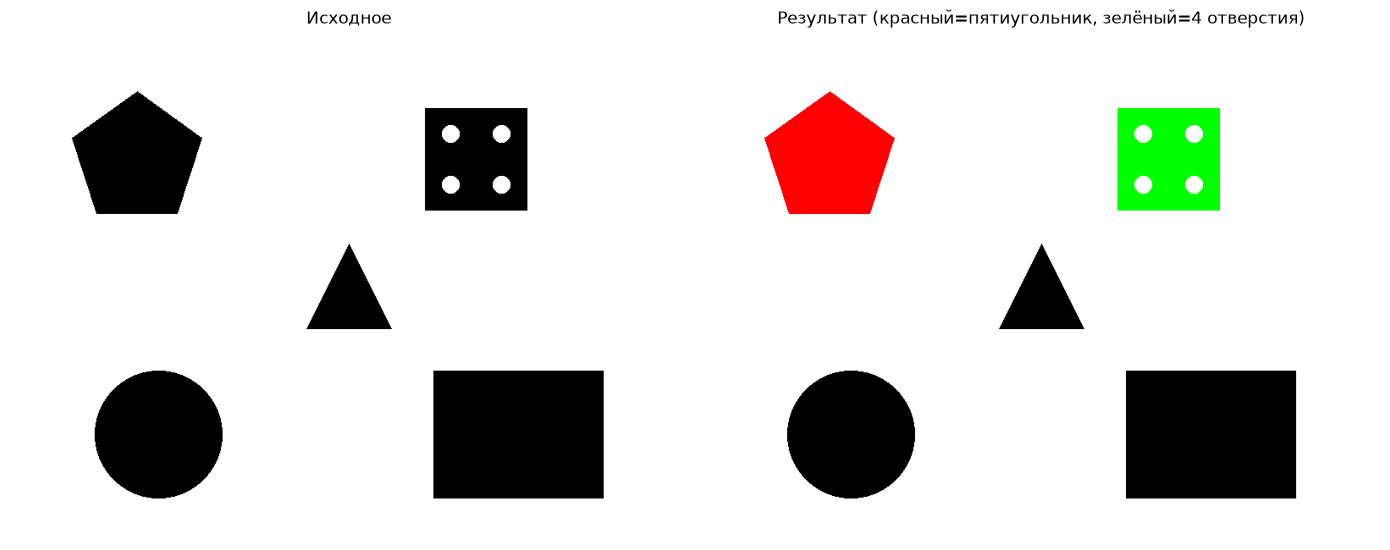


Результат сохранён как 'result_parts.png'


In [37]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(image_np)
ax[0].set_title('Исходное')
ax[0].axis('off')
ax[1].imshow(result)
ax[1].set_title('Результат (красный=пятиугольник, зелёный=4 отверстия)')
ax[1].axis('off')
plt.tight_layout()
plt.show()

# Сохранение результата
result_pil = Image.fromarray(result)
result_pil.save(ROOT_DIR / "data/result_parts.png")
print("\nРезультат сохранён как 'result_parts.png'")